# EuroSAT RGB Land Cover Classification Using ResNet18

## Team Memebers:
- Avani Kasar
- V. Kavyanjali

### Objective 
To classify satellite images from the EuroSAT RGB dataset into 10 land cover classes using a deep learning model (ResNet18) implemented in PyTorch.

In [19]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cpu


In [3]:
# Hyperparameters

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 10

In [4]:
train_dir = "EuroSAT/train"
val_dir = "EuroSAT/val"

print("Training folder:", train_dir)
print("Validation folder:", val_dir)

Training folder: EuroSAT/train
Validation folder: EuroSAT/val


In [5]:
# Data Transformations

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

In [6]:
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

class_names = train_dataset.classes

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=val_transform
)

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [8]:
print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))

print("\nClasses:")
print(train_dataset.classes)

Training Images: 18900
Validation Images: 4050

Classes:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


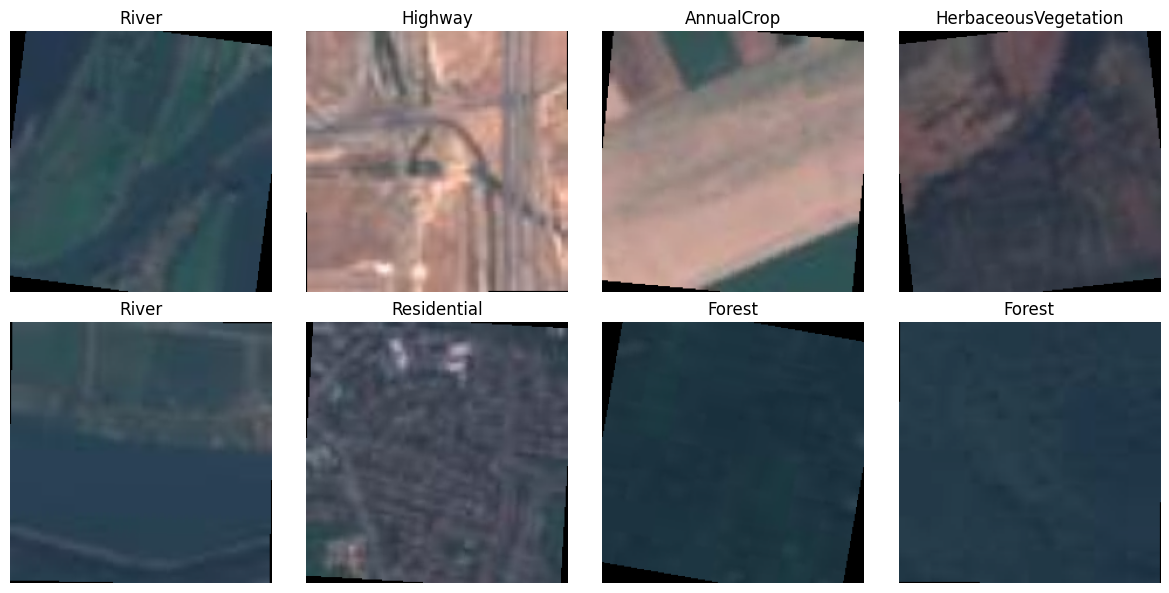

In [9]:
# Get one batch of images
images, labels = next(iter(train_loader))

# Convert tensor to NumPy for plotting
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()

    # Undo normalization for display
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# Load pre-trained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [11]:
# Replace the final fully connected layer
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Move model to CPU/GPU
model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


In [12]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

In [13]:
print("Device:", device)
print("Classes:", NUM_CLASSES)
print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning Rate:", LEARNING_RATE)

Device: cpu
Classes: 10
Batch Size: 32
Epochs: 10
Learning Rate: 0.001


In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        progress_bar.set_postfix(
            Loss=f"{loss.item():.4f}",
            Acc=f"{100*correct/total:.2f}%"
        )

    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
def validate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        dataloader,
        desc="Validation",
        leave=False
    )

    with torch.no_grad():

        for images, labels in progress_bar:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            progress_bar.set_postfix(
                Loss=f"{loss.item():.4f}",
                Acc=f"{100*correct/total:.2f}%"
            )

    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [16]:
best_accuracy = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

start_time = time.time()

print("=" * 60)
print("Starting Training...")
print("=" * 60)

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print("-" * 60)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Training Loss      : {train_loss:.4f}")
    print(f"Training Accuracy  : {train_acc:.2f}%")
    print(f"Validation Loss    : {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.2f}%")

    if val_acc > best_accuracy:

        best_accuracy = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())

        print("⭐ New Best Model Saved!")

    print("-" * 60)

elapsed_time = time.time() - start_time

print("\n" + "=" * 60)
print("🎉 Training Complete!")
print("=" * 60)
print(f"Best Validation Accuracy : {best_accuracy:.2f}%")
print(f"Total Training Time      : {elapsed_time/60:.2f} minutes")
print("=" * 60)

Starting Training...

Epoch [1/10]
------------------------------------------------------------


Training Loss      : 0.6104
Training Accuracy  : 79.92%
Validation Loss    : 0.3386
Validation Accuracy: 88.25%
⭐ New Best Model Saved!
------------------------------------------------------------

Epoch [2/10]
------------------------------------------------------------


Training Loss      : 0.3735
Training Accuracy  : 87.77%
Validation Loss    : 0.3176
Validation Accuracy: 89.63%
⭐ New Best Model Saved!
------------------------------------------------------------

Epoch [3/10]
------------------------------------------------------------


Training Loss      : 0.3002
Training Accuracy  : 89.81%
Validation Loss    : 0.2639
Validation Accuracy: 91.51%
⭐ New Best Model Saved!
------------------------------------------------------------

Epoch [4/10]
------------------------------------------------------------


Training Loss      : 0.2871
Training Accuracy  : 90.39%
Validation Loss    : 0.2073
Validation Accuracy: 92.84%
⭐ New Best Model Saved!
------------------------------------------------------------

Epoch [5/10]
------------------------------------------------------------


...

Training Loss      : 0.2438
Training Accuracy  : 91.56%
Validation Loss    : 0.3194
Validation Accuracy: 90.15%
------------------------------------------------------------

Epoch [7/10]
------------------------------------------------------------


Training Loss      : 0.2367
Training Accuracy  : 91.96%
Validation Loss    : 0.2063
Validation Accuracy: 93.43%
⭐ New Best Model Saved!
------------------------------------------------------------

Epoch [8/10]
------------------------------------------------------------


Training Loss      : 0.2359
Training Accuracy  : 91.96%
Validation Loss    : 0.2084
Validation Accuracy: 92.81%
------------------------------------------------------------

Epoch [9/10]
------------------------------------------------------------


Training Loss      : 0.2112
Training Accuracy  : 92.79%
Validation Loss    : 0.2384
Validation Accuracy: 91.93%
------------------------------------------------------------

Epoch [10/10]
------------------------------------------------------------


Training Loss      : 0.2061
Training Accuracy  : 93.02%
Validation Loss    : 0.1946
Validation Accuracy: 93.11%
------------------------------------------------------------

🎉 Training Complete!
Best Validation Accuracy : 93.43%
Total Training Time      : 1618.69 minutes


In [ ]:
# Loading the best model
model.load_state_dict(torch.load("best_resnet18_eurosat.pth"))
model.eval()

In [ ]:
torch.save(model.state_dict(), "best_resnet18_eurosat.pth")

print("Model saved successfully!")

In [14]:
class_names = train_dataset.classes

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

model.load_state_dict(torch.load("best_resnet18_eurosat.pth"))

model = model.to(device)

model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [15]:
# Evaluation on the validation set

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

## Classification Report

In [16]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                      precision    recall  f1-score   support

          AnnualCrop       0.89      0.97      0.93       450
              Forest       0.94      0.98      0.96       450
HerbaceousVegetation       0.92      0.87      0.90       450
             Highway       0.97      0.85      0.91       375
          Industrial       0.88      0.99      0.93       375
             Pasture       0.92      0.94      0.93       300
       PermanentCrop       0.90      0.87      0.88       375
         Residential       0.98      0.97      0.98       450
               River       0.96      0.90      0.93       375
             SeaLake       0.98      0.98      0.98       450

            accuracy                           0.93      4050
           macro avg       0.93      0.93      0.93      4050
        weighted avg       0.94      0.93      0.93      4050



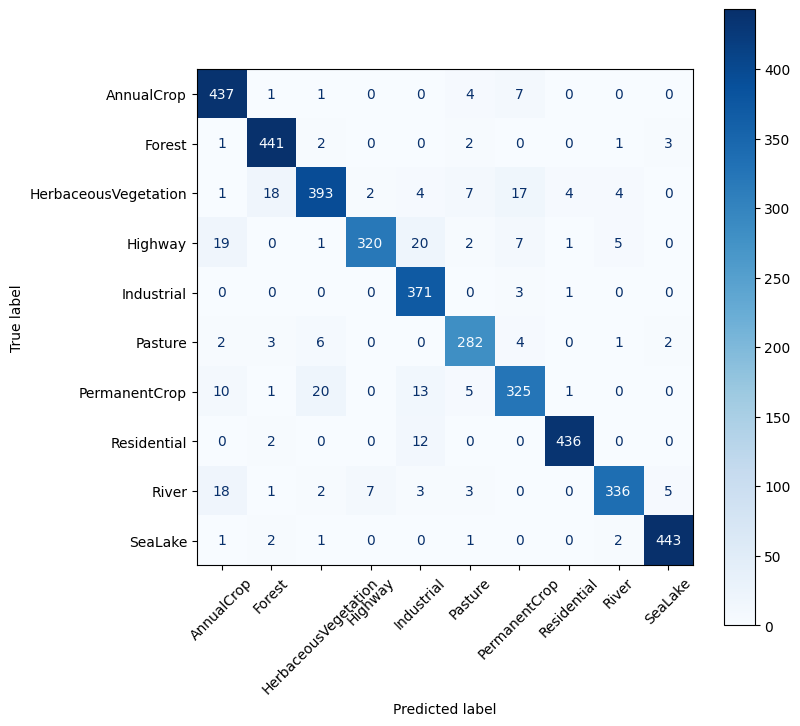

In [17]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.show()

In [20]:

# Path to unseen images
test_dir = "EuroSAT_test_flat"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

results = []

with torch.no_grad():
    for img_name in tqdm(sorted(os.listdir(test_dir))):

        if not img_name.lower().endswith((".jpg", ".jpeg", ".png", ".tif")):
            continue

        img_path = os.path.join(test_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        image = transform(image).unsqueeze(0).to(device)

        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)

        confidence, pred = torch.max(probs, 1)

        results.append({
            "image": img_name,
            "predicted_class": class_names[pred.item()],
            "confidence": float(confidence.item())
        })

pred_df = pd.DataFrame(results)
pred_df.head()

100%|██████████| 4050/4050 [47:18<00:00,  1.43it/s]


,image,predicted_class,confidence
0,test_1.jpg,AnnualCrop,0.932909
1,test_10.jpg,AnnualCrop,0.977971
2,test_100.jpg,AnnualCrop,0.983615
3,test_1000.jpg,HerbaceousVegetation,0.934857
4,test_1001.jpg,HerbaceousVegetation,0.995569


In [21]:
pred_df.to_csv("unseen_test_predictions.csv", index=False)

print("Predictions saved successfully!")

Predictions saved successfully!


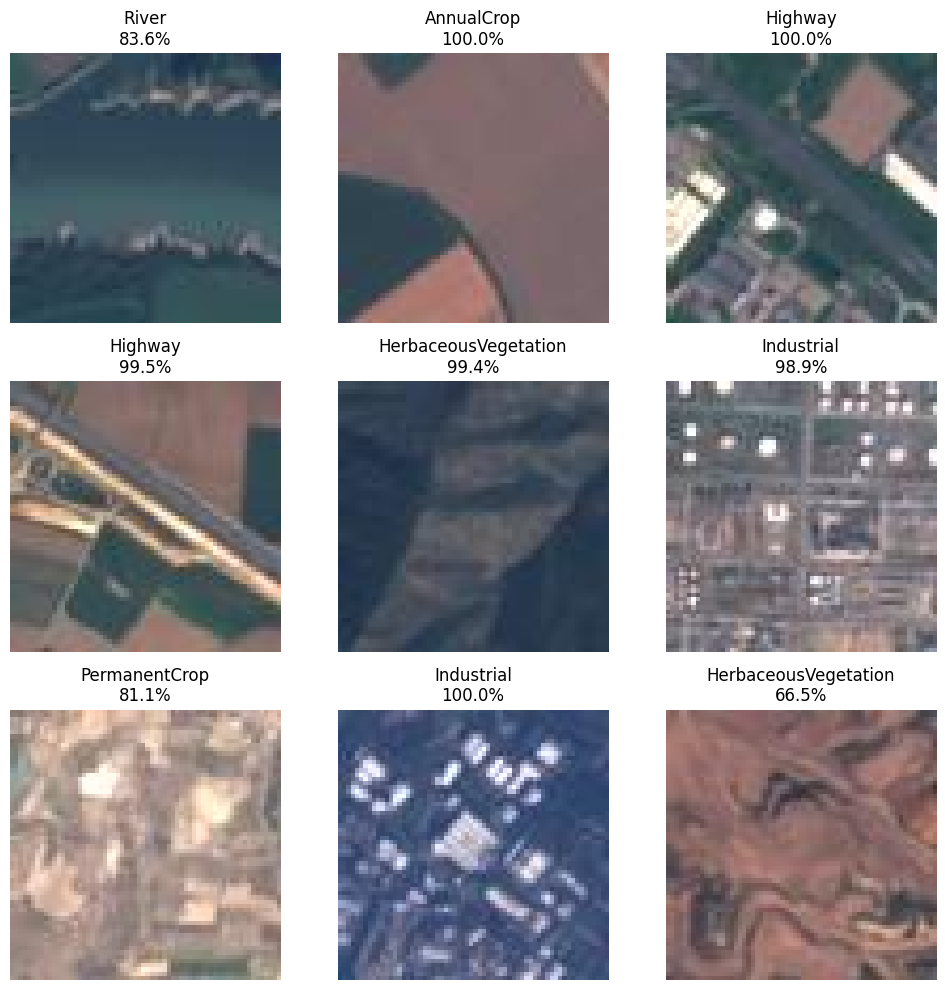

In [22]:
import matplotlib.pyplot as plt
import random

sample_images = random.sample(results, 9)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for ax, item in zip(axes.ravel(), sample_images):
    img = Image.open(os.path.join(test_dir, item["image"]))

    ax.imshow(img)
    ax.set_title(
        f'{item["predicted_class"]}\n'
        f'{item["confidence"]*100:.1f}%'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## Error analysis (Using Validation Set)

#### Number of correct predictions each class

In [23]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_true, y_pred)

results = pd.DataFrame({
    "Class": class_names,
    "Correct Predictions": cm.diagonal(),
    "Total Images": cm.sum(axis=1)
})

results["Incorrect Predictions"] = (
    results["Total Images"] - results["Correct Predictions"]
)

results["Accuracy (%)"] = (
    results["Correct Predictions"] /
    results["Total Images"] * 100
).round(2)

results

,Class,Correct Predictions,Total Images,Incorrect Predictions,Accuracy (%)
0,AnnualCrop,437,450,13,97.11
1,Forest,441,450,9,98.00
2,HerbaceousVegetation,393,450,57,87.33
3,Highway,320,375,55,85.33
4,Industrial,371,375,4,98.93
5,Pasture,282,300,18,94.00
6,PermanentCrop,325,375,50,86.67
7,Residential,436,450,14,96.89
8,River,336,375,39,89.60
9,SeaLake,443,450,7,98.44
